In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = fetch_openml(name='boston', version=1, as_frame=True)
X = data.data
y = data.target.astype('float')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48


In [3]:
y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: MEDV, Length: 404, dtype: float64

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)
X_train_scaled.min(), X_train_scaled.max()

(np.float64(-3.892248541744519), np.float64(9.630688843769592))

In [5]:
class RegressionDNN(nn.Module):
    def __init__(self):
        super(RegressionDNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(13,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.network(x)

In [6]:
model = RegressionDNN()
lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 1100

In [7]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    predictions = model(X_train_tensor)
    loss = lossFunction(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor)
    test_loss = lossFunction(test_predictions, y_test_tensor)
print(f'Test Loss: {test_loss.item():.4f}')

for i in range(5):
    print(f'Predicted: {test_predictions[i].item():.2f}, Actual: {y_test_tensor[i].item():.2f}')


Epoch 10/1100, Loss: 585.8417
Epoch 20/1100, Loss: 566.2543
Epoch 30/1100, Loss: 537.4368
Epoch 40/1100, Loss: 496.2840
Epoch 50/1100, Loss: 439.7163
Epoch 60/1100, Loss: 367.5729
Epoch 70/1100, Loss: 284.3499
Epoch 80/1100, Loss: 201.7249
Epoch 90/1100, Loss: 135.5722
Epoch 100/1100, Loss: 94.1055
Epoch 110/1100, Loss: 70.9832
Epoch 120/1100, Loss: 55.7640
Epoch 130/1100, Loss: 44.4772
Epoch 140/1100, Loss: 36.7093
Epoch 150/1100, Loss: 31.7239
Epoch 160/1100, Loss: 28.5501
Epoch 170/1100, Loss: 26.4553
Epoch 180/1100, Loss: 24.9811
Epoch 190/1100, Loss: 23.8403
Epoch 200/1100, Loss: 22.8808
Epoch 210/1100, Loss: 22.0260
Epoch 220/1100, Loss: 21.2486
Epoch 230/1100, Loss: 20.5247
Epoch 240/1100, Loss: 19.8362
Epoch 250/1100, Loss: 19.1827
Epoch 260/1100, Loss: 18.5727
Epoch 270/1100, Loss: 18.0015
Epoch 280/1100, Loss: 17.4638
Epoch 290/1100, Loss: 16.9591
Epoch 300/1100, Loss: 16.4894
Epoch 310/1100, Loss: 16.0529
Epoch 320/1100, Loss: 15.6501
Epoch 330/1100, Loss: 15.2736
Epoch 340/

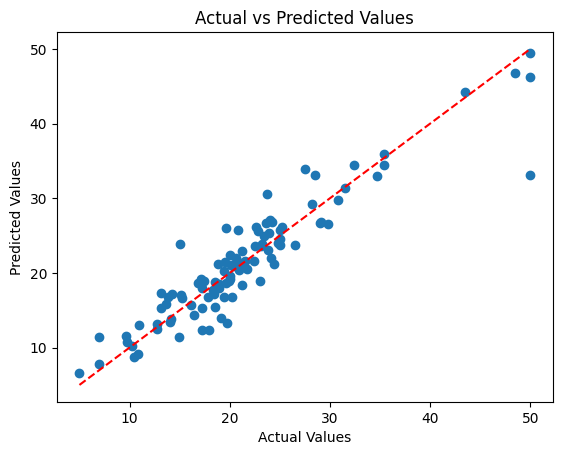

In [8]:
import matplotlib.pyplot as plt
plt.scatter(y_test_tensor.numpy(), test_predictions.numpy())
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.plot([y_test_tensor.min(), y_test_tensor.max()], [y_test_tensor.min(), y_test_tensor.max()], 'r--')
plt.show()

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test_tensor.numpy(), test_predictions.numpy())
r2 = r2_score(y_test_tensor.numpy(), test_predictions.numpy())
print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')


Mean Squared Error: 9.7456
R^2 Score: 0.8671
